# modexp.py test

- https://github.com/Qiskit/qiskit/blob/stable/2.3/qiskit/synthesis/arithmetic/adders/vbe_ripple_carry_adder.py
- VBE article

---
$\renewcommand{\ket}[1]{|#1\rangle}$

In Shor/QPE we need the unitary map $\ket{x}\ket{z} \to \ket{x}\ket{y^x z \mod N}$.



## Setup

In [96]:
import sys
sys.path.append('.')  

from modexp import ModExpTools
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import circuit_drawer
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

---
# 1. Elementary Gates

## 1.1 CARRIER Gate 
The carry bit, $c_i$, corresponding to the sum of $i$th bits can be calculated with the help of carry generated by i-1 th sum and $a_i$, $b_i$ which is $$c_i=(c_{i-1}\wedge a_{i-1})\vee (a_{i-1}\wedge b_{i-1})\vee (b_{i-1}\wedge c_{i-1}).$$

- $CNOT \ket{a,b}\to     \ket{a,a\oplus b}$ (=XOR)
- $TOFFOLI \ket{a,b,c}\to     \ket{a,b,c\oplus (a\cdot b)}$ (=AND on target)

Carry circuit:

<img src="imgs/carry.png" width="300" height="200" alt="carry">

Step 1: $ \ket{a_i, b_i, c_{i+1}}\to     \ket{a_i, b_i, c_{i+1} \oplus (a_i·b_i)}$

Step 2: $ \ket{a_i, b_i}\to     \ket{a_i, b_i \oplus a_i⟩}$

Step 3: $ \ket{b_i\oplus a_i, c_i, c_{i+1}}\to    aggiorna \ c_{i+1}$

Step 4: $ ripristina \ b_i$


=== CARRIER GATE ===
Numero di qubits: 4
Label: carrier

Circuito CARRIER:


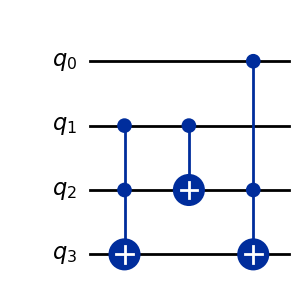


Gate elementari:
  - ccx
  - cx
  - ccx

Totale gate: 3


In [97]:
carrier = ModExpTools.create_carrier()

print("=== CARRIER GATE ===")
print(f"Numero di qubits: {carrier.num_qubits}")
print(f"Label: {carrier.label}")
print()

qc_carrier = QuantumCircuit(4)
qc_carrier.append(carrier, range(4))

print("Circuito CARRIER:")
display(qc_carrier.decompose().draw('mpl'))
print("\nGate elementari:")
decomposed = qc_carrier.decompose()
for instruction in decomposed.data:
    print(f"  - {instruction.operation.name}")

print(f"\nTotale gate: {len(decomposed.data)}")

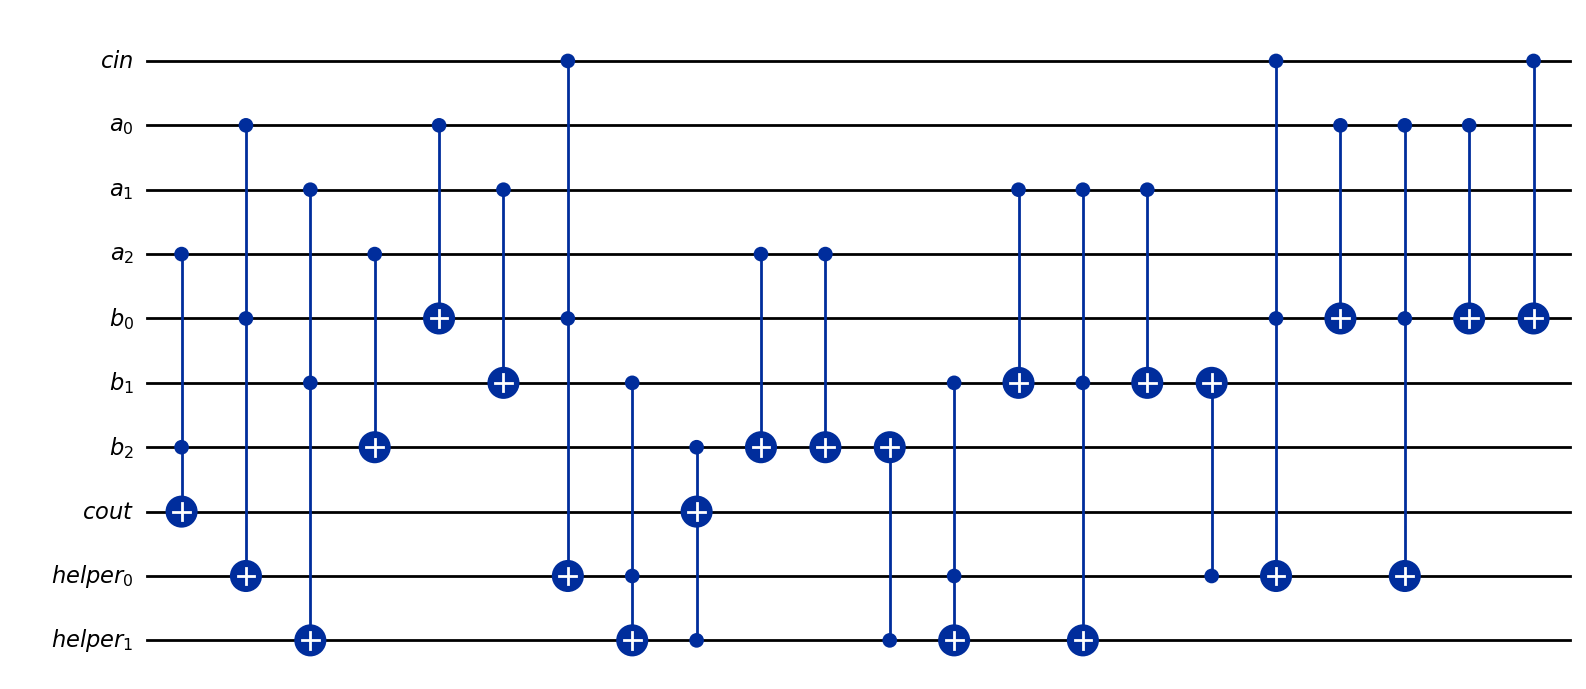

In [80]:
from qiskit.circuit.library import VBERippleCarryAdder

n = 3
adder = VBERippleCarryAdder(n, name="VBE")

# circuito interno (decomposizione in porte elementari)
# adder_decomp = adder.decompose()          # una decomposizione
adder_decomp = adder.decompose().decompose()  

adder_decomp.draw("mpl")


## funzione



In [81]:

print("\n c a b | Expected | Measured | Status")
print("-" * 50)

all_pass = True

for c in [0, 1]:
    for a in [0, 1]:
        for b in [0, 1]:
            # CARRIER atteso
            carr = (a & b) ^ (a & c) ^ (b & c)
            
            qc = QuantumCircuit(4, 1)
            
            # prepare input |c, a, b, 0>
            if c: qc.x(0)
            if a: qc.x(1)
            if b: qc.x(2)
            
            # apply CARRIER
            qc.append(carrier, range(4))
            
            # misura output bit
            qc.measure(3, 0)
            
            simulator = AerSimulator()
            from qiskit import transpile
            tqc = transpile(qc, simulator, optimization_level=0)  
            result = simulator.run(tqc, shots=1).result()
            counts = result.get_counts()
            measured = int(list(counts.keys())[0])
            
            status = "ok" if measured == carr else "nope"
            if measured != carr:
                all_pass = False
            
            print(f"{c} {a} {b} |      {carr}       |    {measured}     | {status}")

print()
if all_pass:
    print("CARRIER gate corretto!")
else:
    print("CARRIER gate NON corretto!")


 c a b | Expected | Measured | Status
--------------------------------------------------
0 0 0 |      0       |    0     | ok
0 0 1 |      0       |    0     | ok
0 1 0 |      0       |    0     | ok
0 1 1 |      1       |    1     | ok
1 0 0 |      0       |    0     | ok
1 0 1 |      1       |    1     | ok
1 1 0 |      1       |    1     | ok
1 1 1 |      1       |    1     | ok

CARRIER gate corretto!


## 1.2 SUM Gate

This calculates the sum of bits corresponding bits along with the carry. That can be calculated by again the carry generated by the previous bit pair and $a_i, b_i$ which is $$s_i=c_{i}\oplus a_i\oplus b_i$$

<img src="imgs/sum.png" width="300" height="200" alt="carry">

Step 1: $ \ket{c_i,b_1} \to\ket{c_i,b_i\otimes c_i} $

Step 2: $ \ket{a_i,b_1} \to\ket{a_i,b_i\otimes a_i} $

=== SUM GATE ===
Numero di qubits: 3

Circuito SUM:


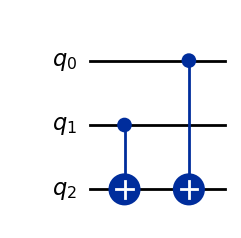


Gate elementari:
  - cx
  - cx

Totale gate: 2

SUM = 2 CNOT per XOR a 3 vie


In [82]:
sum_gate = ModExpTools.create_sum()

print("=== SUM GATE ===")
print(f"Numero di qubits: {sum_gate.num_qubits}")
print()

qc_sum = QuantumCircuit(3)
qc_sum.append(sum_gate, range(3))

print("Circuito SUM:")
display(qc_sum.decompose().draw('mpl'))

print("\nGate elementari:")
decomposed = qc_sum.decompose()
for instruction in decomposed.data:
    print(f"  - {instruction.operation.name}")

print(f"\nTotale gate: {len(decomposed.data)}")
print("\nSUM = 2 CNOT per XOR a 3 vie")

## Funzione

In [83]:

print("c a b | Expected | Measured | Status")
print("-" * 45)

all_pass = True

for c in [0, 1]:
    for a in [0, 1]:
        for b in [0, 1]:
            # XOR atteso
            expected = c ^ a ^ b
            
            # Crea circuito
            qc = QuantumCircuit(3, 1)
            
            # Input |c, a, b>
            if c: qc.x(0)
            if a: qc.x(1)
            if b: qc.x(2)
            
            # SUM
            qc.append(sum_gate, range(3))
            
            # target è qubit 2, misura su bit classico 0
            qc.measure(2, 0)
            
            simulator = AerSimulator()
            from qiskit import transpile
            tqc = transpile(qc, simulator, optimization_level=0) 
            result = simulator.run(tqc, shots=1).result()
            counts = result.get_counts()
            measured = int(list(counts.keys())[0])
            
            status = "ok" if measured == expected else "nope"
            if measured != expected:
                all_pass = False
            
            print(f"{c} {a} {b} |    {expected}     |    {measured}     | {status}")

print()
if all_pass:
    print("ok SUM gate corretto!")
else:
    print("nope SUM gate NON corretto!")

c a b | Expected | Measured | Status
---------------------------------------------
0 0 0 |    0     |    0     | ok
0 0 1 |    1     |    1     | ok
0 1 0 |    1     |    1     | ok
0 1 1 |    0     |    0     | ok
1 0 0 |    1     |    1     | ok
1 0 1 |    0     |    0     | ok
1 1 0 |    0     |    0     | ok
1 1 1 |    1     |    1     | ok

ok SUM gate corretto!


---
# 2. Plain Adder

$\renewcommand{\ket}[1]{|#1\rangle}$
This circuit is used to carry out addition of two states $\ket{a}$ and $\ket{b}$ using the following unitary gate $$\ket{a,b}\to \ket{a,a+b}$$



## 2.1  Circuito

<img src="imgs/adder.png" width="1000" height="400" alt="add">

uses that in binary we can sum any number with

- $n_i = a_i \oplus  b_i \oplus c_i $ = the result is 1 if the number of 1s between a,b,c is dispari 

- $carry_{i+1} = (a_i \cdot b_i) \oplus (a_i \cdot c_i) \oplus  (b_i \cdot c_i) $ = if two bits ore more are 1s then we have carry


=== PLAIN ADDER (n=3) ===
Numero totale di qubits: 10
  - a: 3 qubits
  - b: 4 qubits (con overflow)
  - c: 3 qubits (carry)

Circuito ADDER (compresso):


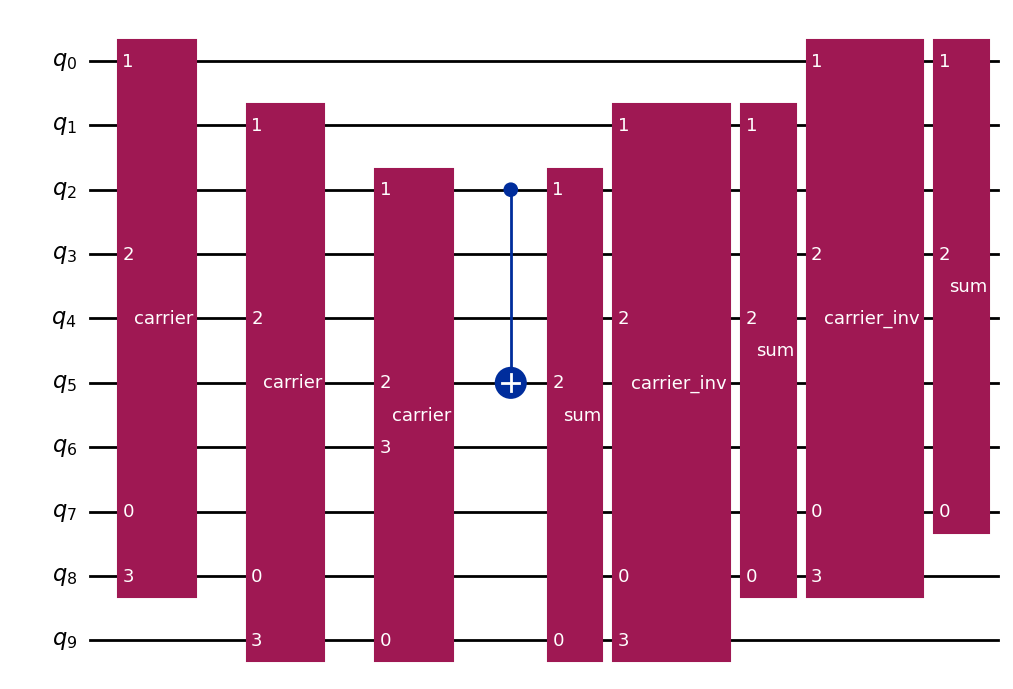


Numero di gate elementari: 9
Complessità: O(n) = O(3)


In [84]:
# adder per numeri a 3 bit
n = 3
adder = ModExpTools.create_adder(n)

print(f"=== PLAIN ADDER (n={n}) ===")
print(f"Numero totale di qubits: {adder.num_qubits}")
print(f"  - a: {n} qubits")
print(f"  - b: {n+1} qubits (con overflow)")
print(f"  - c: {n} qubits (carry)")
print()

qc_adder = QuantumCircuit(3*n + 1)
qc_adder.append(adder, range(3*n + 1))

print("Circuito ADDER (compresso):")
display(qc_adder.decompose().draw('mpl', fold=-1))

decomposed = qc_adder.decompose()
gate_count = len(decomposed.data)
print(f"\nNumero di gate elementari: {gate_count}")
print(f"Complessità: O(n) = O({n})")

## 2.2 Test funzione Adder

In [85]:
def test_adder(a_val, b_val, n):
    a = QuantumRegister(n, 'a')
    b = QuantumRegister(n + 1, 'b')
    c = QuantumRegister(n, 'c')
    cb = ClassicalRegister(n + 1, 'cb')
    
    qc = QuantumCircuit(a, b, c, cb)
    
    #  inizializza a
    for i, bit in enumerate(bin(a_val)[2:][::-1]):
        if bit == '1' and i < n:
            qc.x(a[i])
    
    #  inizializza b
    for i, bit in enumerate(bin(b_val)[2:][::-1]):
        if bit == '1' and i < n:
            qc.x(b[i])
    
    #  applica adder
    qc.append(ModExpTools.create_adder(n), list(a) + list(b) + list(c))
    
    # misura b (contiene a+b)
    qc.measure(b, cb)
    
    simulator = AerSimulator()
    from qiskit import transpile
    tqc = transpile(qc, simulator, optimization_level=0)  
    result = simulator.run(tqc, shots=1).result()
    counts = result.get_counts()
    measured = list(counts.keys())[0]
    result_val = int(measured, 2)
    
    expected = a_val + b_val
    passed = (result_val == expected)
    
    return result_val, expected, passed

 
print("=== TEST ADDER ===")
print("a  + b  = Expected | Measured | Status")
print("-" * 45)

n = 4  # 4-bit adder
test_cases = [
    (3, 5),    # 3 + 5 = 8
    (7, 9),    # 7 + 9 = 16
    (15, 1),   # 15 + 1 = 16
    (0, 10),   # 0 + 10 = 10
    (12, 7),   # 12 + 7 = 19
]

all_pass = True
for a_val, b_val in test_cases:
    result, expected, passed = test_adder(a_val, b_val, n)
    status = "ok" if passed else "nope"
    if not passed:
        all_pass = False
    print(f"{a_val:2d} + {b_val:2d} = {expected:3d}      | {result:3d}      | {status}")

print()
if all_pass:
    print("ok ADDER funziona correttamente!")
else:
    print("ADDER ha errori!")

=== TEST ADDER ===
a  + b  = Expected | Measured | Status
---------------------------------------------
 3 +  5 =   8      |   8      | ok
 7 +  9 =  16      |  16      | ok
15 +  1 =  16      |  16      | ok
 0 + 10 =  10      |  10      | ok
12 +  7 =  19      |  19      | ok

ok ADDER funziona correttamente!


---
# 3. Modular Adder

## 3.1 Circuito

<img src="imgs/modular_adder.png" width="1000" height="400" alt="carry">

1. simple adder: a+b

2. subtract N. If the overflow bit is 0 we had $a+b\ge N$ which is ok. If is 1 then we need to sum back N.



=== MODULAR ADDER (n=4, N=15) ===
Numero totale di qubits: 18
  - a: 4 qubits
  - b: 5 qubits
  - c: 4 qubits (carry)
  - bN: 4 qubits (stores N)
  - t: 1 qubit (flag)



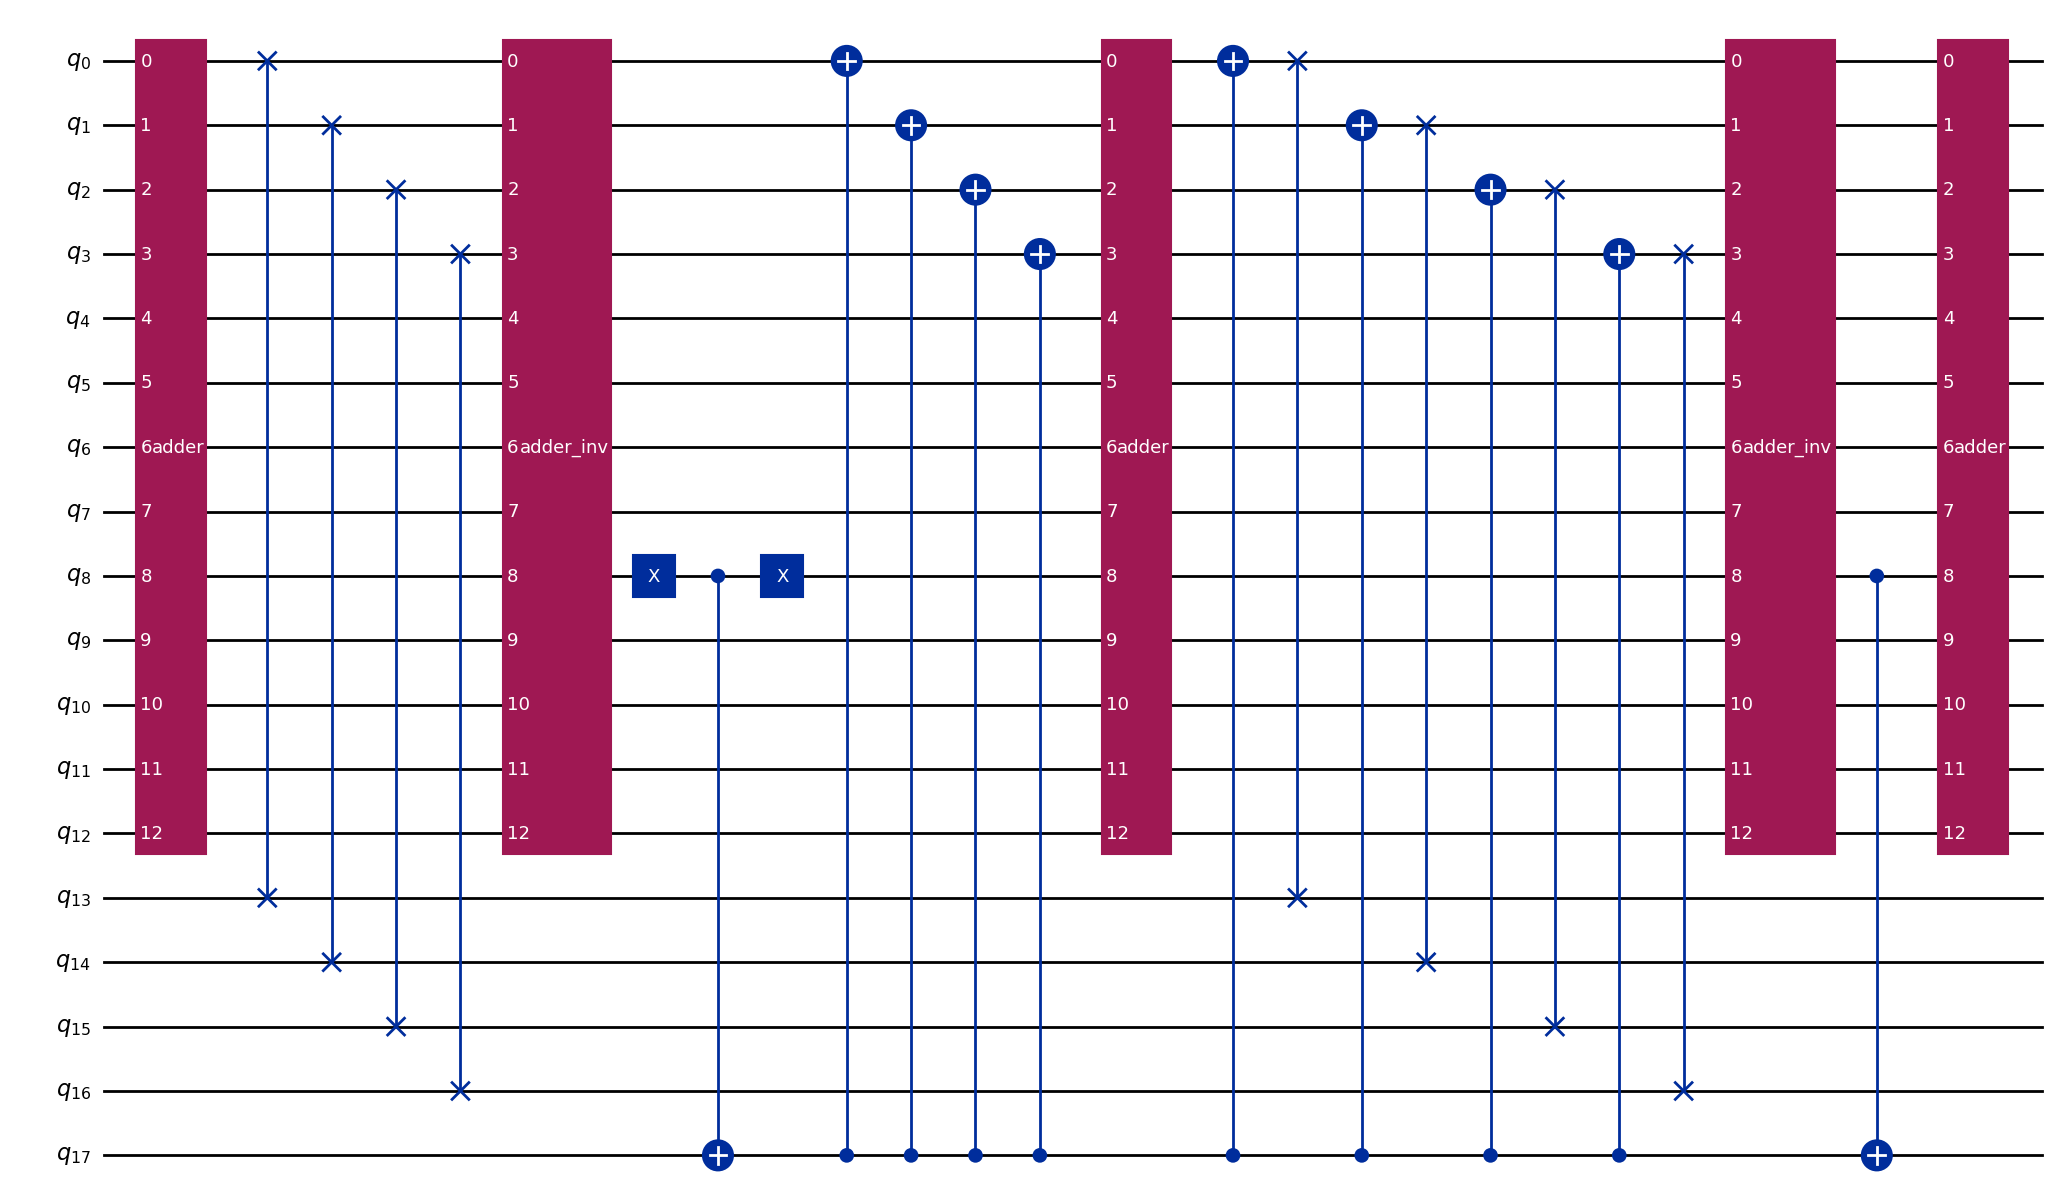


Numero di gate: 25
Complessità: O(n) = O(4)


In [95]:
n = 4
N = 15 

adder_mod = ModExpTools.create_adder_mod(n, N)

print(f"=== MODULAR ADDER (n={n}, N={N}) ===")
print(f"Numero totale di qubits: {adder_mod.num_qubits}")
print(f"  - a: {n} qubits")
print(f"  - b: {n+1} qubits")
print(f"  - c: {n} qubits (carry)")
print(f"  - bN: {n} qubits (stores N)")
print(f"  - t: 1 qubit (flag)")
print()

qc_adder_mod = QuantumCircuit(4*n + 2)
qc_adder_mod.append(adder_mod, range(4*n + 2))

# visualizza circuito completo
display(qc_adder_mod.decompose().draw('mpl', fold=-1))  

# conta gate
decomposed = qc_adder_mod.decompose()
gate_count = len(decomposed.data)
print(f"\nNumero di gate: {gate_count}")
print(f"Complessità: O(n) = O({n})")

## 3.2 Test funzione Modular Adder

In [87]:
def test_adder_mod(a_val, b_val, N, n):    
    a = QuantumRegister(n, 'a')
    b = QuantumRegister(n + 1, 'b')
    c = QuantumRegister(n, 'c')
    bN = QuantumRegister(n, 'bN')
    t = QuantumRegister(1, 't')
    cb = ClassicalRegister(n + 1, 'cb')
    
    qc = QuantumCircuit(a, b, c, bN, t, cb)
    
    #  inizializza a
    for i, bit in enumerate(bin(a_val)[2:][::-1]):
        if bit == '1' and i < n:      
            qc.x(a[i])
    
    #  inizializza b
    for i, bit in enumerate(bin(b_val)[2:][::-1]):
        if bit == '1' and i < n:
            qc.x(b[i])
    
    for i, bit in enumerate(bin(N)[2:][::-1]):
        if bit == '1' and i < n:
            qc.x(bN[i])

    # adder mod
    qc.append(
        ModExpTools.create_adder_mod(n, N),
        list(a) + list(b) + list(c) + list(bN) + list(t)
    )
    
    # misura b
    qc.measure(b, cb)
    
    simulator = AerSimulator()
    from qiskit import transpile
    tqc = transpile(qc, simulator, optimization_level=0)  
    result = simulator.run(tqc, shots=1).result()
    counts = result.get_counts()
    measured = list(counts.keys())[0]
    result_val = int(measured, 2)
    
    expected = (a_val + b_val) % N
    passed = (result_val == expected)
    
    return result_val, expected, passed

print("=== TEST MODULAR ADDER ===")
print(f"Modulus N = {N}")
print()
print("a  + b  = Expected | Measured | Status")
print("-" * 45)

n = 4
N = 15

test_cases = [
    (3, 5),    # (3 + 5) mod 15 = 8
    (7, 9),    # (7 + 9) mod 15 = 1
    (10, 8),   # (10 + 8) mod 15 = 3
    (14, 1),   # (14 + 1) mod 15 = 0
    (0, 7),    # (0 + 7) mod 15 = 7
]

all_pass = True
for a_val, b_val in test_cases:
    result, expected, passed = test_adder_mod(a_val, b_val, N, n)
    status = "ok" if passed else "nope"
    if not passed:
        all_pass = False
    print(f"{a_val:2d} + {b_val:2d} = {expected:3d}      | {result:3d}      | {status}")

print()
if all_pass:
    print("ok ADDER MOD funziona correttamente!")
else:
    print("nope ADDER MOD ha errori!")

=== TEST MODULAR ADDER ===
Modulus N = 15

a  + b  = Expected | Measured | Status
---------------------------------------------
 3 +  5 =   8      |   8      | ok
 7 +  9 =   1      |   1      | ok
10 +  8 =   3      |   3      | ok
14 +  1 =   0      |   0      | ok
 0 +  7 =   7      |   7      | ok

ok ADDER MOD funziona correttamente!


---
# 4. Controlled Modular Multiplication
$$ \ket{c,x,0} \to \ket{a,x,ax\mod N}  $$
if |c>=1. 


- we can write ax as a conditional sum of powers of 2

$$ ax = a\cdot (x_0\cdot 2^0 + x_1 2^1 + x_2 2^2 +\dots)$$

if $x_i = 1$ we need to sum $2^i a \mod N $. 

- the result is 
$$ result = \sum_{i=0}^{n-1} x_i \cdot (2^ia \mod N) \mod N $$

## 4.1 Circuit

<img src="imgs/c_mult.png" width="1000" height="400" alt="carry">



=== CONTROLLED MULT MOD (n=4, N=15, m=7) ===
Operazione: |c,z,0> → |c,z, c·m·z mod N>
Numero totale di qubits: 23



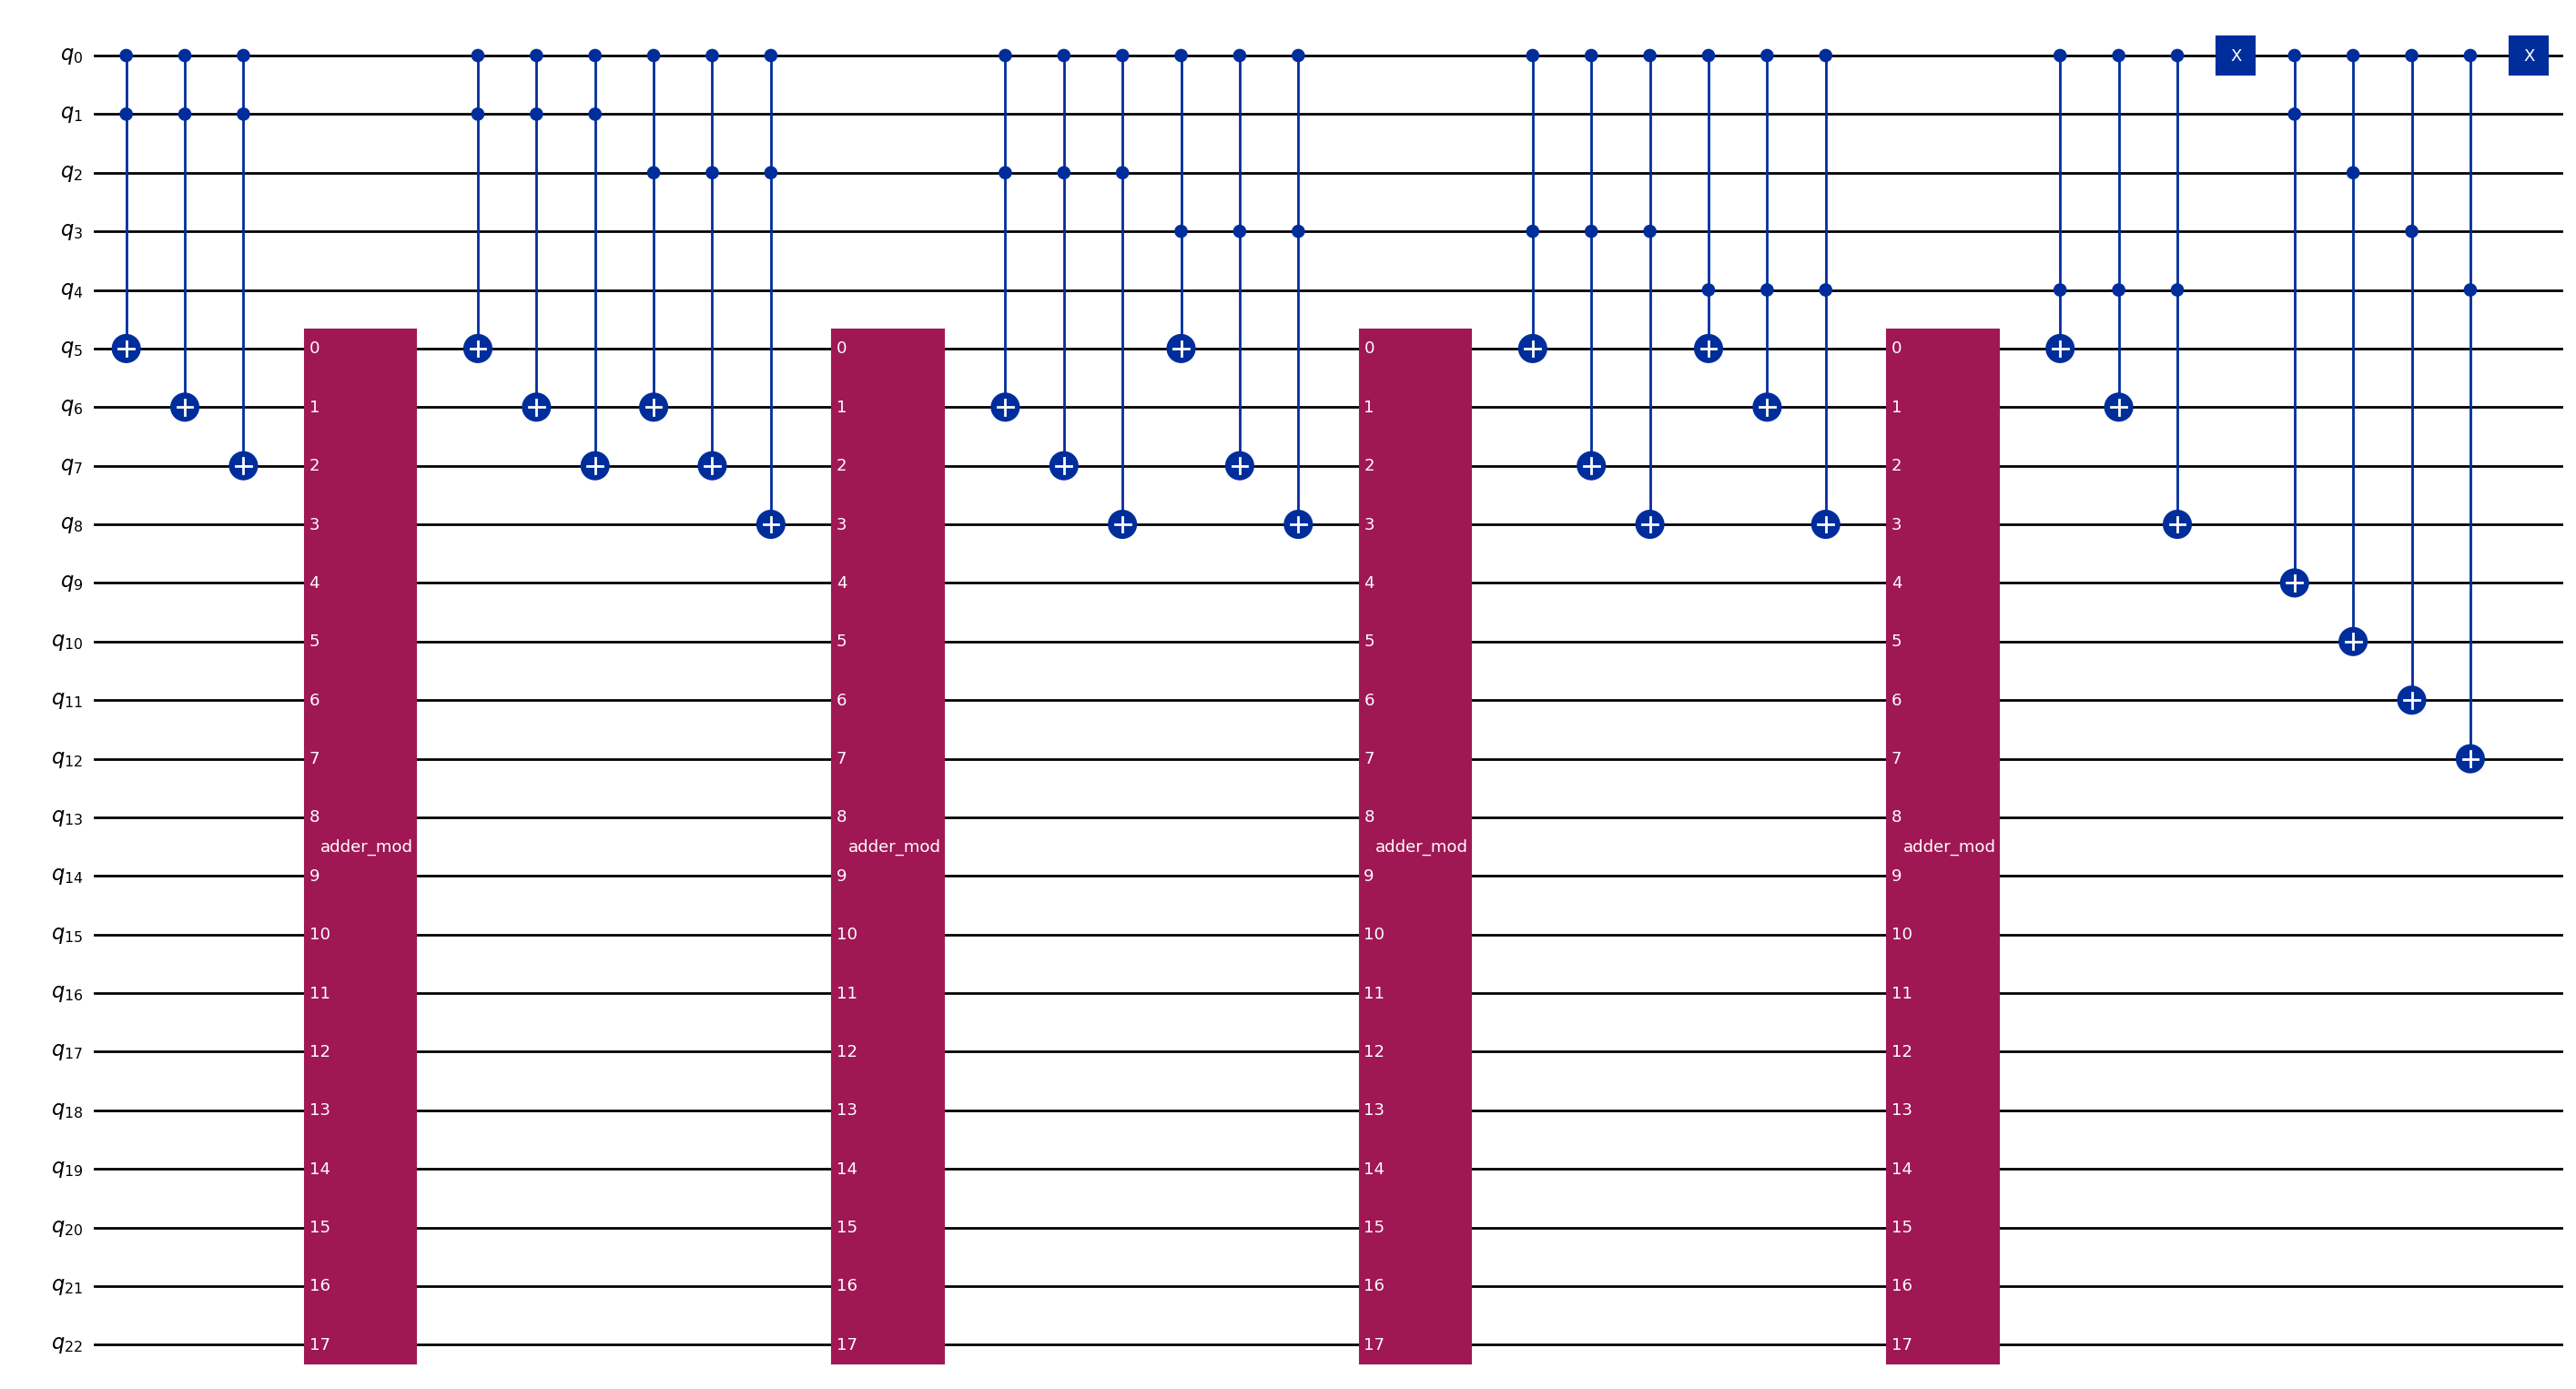

Numero di gate: 34
Complessità: O(n²) = O(4²) = O(16)

[Circuito troppo grande per visualizzazione completa]


In [88]:
n = 4
N = 15
m = 7

ctrl_mult = ModExpTools.create_ctrl_mult_mod(n, N, m)

print(f"=== CONTROLLED MULT MOD (n={n}, N={N}, m={m}) ===")
print(f"Operazione: |c,z,0> → |c,z, c·m·z mod N>")
print(f"Numero totale di qubits: {ctrl_mult.num_qubits}")
print()


qc_mult = QuantumCircuit(5*n + 3)
qc_mult.append(ctrl_mult, range(5*n + 3))
decomposed = qc_mult.decompose()
gate_count = len(decomposed.data)
# draw
display(qc_mult.decompose().draw('mpl', fold=-1))

print(f"Numero di gate: {gate_count}")
print(f"Complessità: O(n²) = O({n}²) = O({n**2})")
print("\n[Circuito troppo grande per visualizzazione completa]")

## 4.2 Test funzione Ctrl Mult Mod

In [89]:
def test_ctrl_mult_mod(c_val, z_val, m, N, n):
    """Test controlled multiplication: if c=1 then b = m*z mod N, else b = z"""
    c = QuantumRegister(1, 'c')
    z = QuantumRegister(n, 'z')
    a = QuantumRegister(n, 'a')
    b = QuantumRegister(n + 1, 'b')
    carry = QuantumRegister(n, 'carry')
    bN = QuantumRegister(n, 'bN')
    t = QuantumRegister(1, 't')
    cb = ClassicalRegister(n, 'cb')  # misura solo n bit di b
    
    qc = QuantumCircuit(c, z, a, b, carry, bN, t, cb)
    
    #  inizializza c (control)
    if c_val:
        qc.x(c[0])
    
    #  inizializza z
    for i, bit in enumerate(bin(z_val)[2:][::-1]):
        if bit == '1' and i < n:
            qc.x(z[i])

    for i, bit in enumerate(bin(N)[2:][::-1]):
        if bit == '1' and i < n:
            qc.x(bN[i])

    #  applica ctrl mult mod
    qc.append(
        ModExpTools.create_ctrl_mult_mod(n, N, m),
        [c[0]] + list(z) + list(a) + list(b) + list(carry) + list(bN) + list(t)
    )
    
    # misura b (primi n bit)
    for i in range(n):
        qc.measure(b[i], cb[i])
    
    
    
    simulator = AerSimulator()
    from qiskit import transpile
    tqc = transpile(qc, simulator, optimization_level=0)  
    result = simulator.run(tqc, shots=1).result()
    counts = result.get_counts()
    measured = list(counts.keys())[0]
    result_val = int(measured, 2)
    
    if c_val == 1:
        expected = (m * z_val) % N
    else:
        expected = z_val
    
    passed = (result_val == expected)
    
    return result_val, expected, passed


print("=== TEST CONTROLLED MULT MOD ===")
print(f"Modulus N = {N}, Multiplier m = {m}")
print()
print("c  z  | Expected | Measured | Status")
print("-" * 45)

n = 4
N = 15
m = 7

test_cases = [
    (1, 2),   # c=1: (7*2) mod 15 = 14
    (1, 3),   # c=1: (7*3) mod 15 = 6
    (0, 5),   # c=0: result = 5
    (1, 8),   # c=1: (7*8) mod 15 = 11
    (0, 10),  # c=0: result = 10
]

all_pass = True
for c_val, z_val in test_cases:
    result, expected, passed = test_ctrl_mult_mod(c_val, z_val, m, N, n)
    status = "ok" if passed else "nope"
    if not passed:
        all_pass = False
    print(f"{c_val}  {z_val:2d} | {expected:3d}      | {result:3d}      | {status}")

print()
if all_pass:
    print("ok CTRL MULT MOD funziona correttamente!")
else:
    print("nope CTRL MULT MOD ha errori!")

=== TEST CONTROLLED MULT MOD ===
Modulus N = 15, Multiplier m = 7

c  z  | Expected | Measured | Status
---------------------------------------------
1   2 |  14      |  14      | ok
1   3 |   6      |   6      | ok
0   5 |   5      |   5      | ok
1   8 |  11      |  11      | ok
0  10 |  10      |  10      | ok

ok CTRL MULT MOD funziona correttamente!


---
# 5. Modular Exponentiation

$$ \ket{x0}\to \ket {x} \ket{a^x \mod N } $$

As before we can use th4e binary representation of x that allows to the exponential to be reduced to conditional multiplications:

$$ a^x = a^{2^0x_0} \cdot a^{2^1 x_1} \cdot a^{2^2 x_2}\cdot \dots $$

There are 3 steps:
- controlled mult: $\ket{A_i,0} \to \ket{A_i,A_i\cdot a^{2^i x_i}}$

- swap:  $\ket{A_i,A_{i+1}} \to \ket{A_{i+1},A_i}$

- invert: $\ket{A_i,A_{i+1}} \to \ket{A_{i+1},0}$

## 5.1 Circuito
<img src="imgs/mod_exp.png" width="1000" height="400" alt="carry">


In [90]:
n = 4
N = 15
y = 7 
nx = 4 

mod_exp = ModExpTools.create_mod_exp(n, N, y, nx)

print(f"=== MODULAR EXPONENTIATION ===")
print(f"Operazione: |x>|1> → |x>|y^x mod N>")
print(f"Parametri: n={n}, N={N}, y={y}, nx={nx}")
print()
print(f"Numero totale di qubits: {mod_exp.num_qubits}")
print(f"  - x: {nx} qubits (esponente)")
print(f"  - z: {n} qubits (risultato)")
print(f"  - Ausiliari: {mod_exp.num_qubits - nx - n} qubits")
print()

# gate count
qc_modexp = QuantumCircuit(nx + 5*n + 2)
qc_modexp.append(mod_exp, range(nx + 5*n + 2))

print(f"Complessità teorica: O(nx·n²) = O({nx}·{n}²) = O({nx * n**2})")


=== MODULAR EXPONENTIATION ===
Operazione: |x>|1> → |x>|y^x mod N>
Parametri: n=4, N=15, y=7, nx=4

Numero totale di qubits: 26
  - x: 4 qubits (esponente)
  - z: 4 qubits (risultato)
  - Ausiliari: 18 qubits

Complessità teorica: O(nx·n²) = O(4·4²) = O(64)


## 5.2 Test funzione Modexp

In [91]:
def test_modexp(base, exponent, modulus):
    """Test modular exponentiation: base^exponent mod modulus"""
    
    try:
        n = modulus.bit_length()
        nx = max(exponent.bit_length() + 1, 2)
        

        x = QuantumRegister(nx, 'x')
        z = QuantumRegister(n, 'z')
        a = QuantumRegister(n, 'a')
        b = QuantumRegister(n + 1, 'b')
        c = QuantumRegister(n, 'c')
        bN = QuantumRegister(n, 'bN')
        t = QuantumRegister(1, 't')
        cz = ClassicalRegister(n, 'cz')
        
        qc = QuantumCircuit(x, z, a, b, c, bN, t, cz)
        
        #  inizializza x con esponente
        for i, bit in enumerate(bin(exponent)[2:][::-1]):
            if bit == '1' and i < nx:
                qc.x(x[i])
        
        # inizializza z a |1> (identità moltiplicativa)
        qc.x(z[0])
        
        for i, bit in enumerate(bin(modulus)[2:][::-1]):
            if bit == '1' and i < n:
                qc.x(bN[i])

        # applica modexp
        qc.append(
            ModExpTools.create_mod_exp(n, modulus, base, nx),
            list(x) + list(z) + list(a) + list(b) + list(c) + list(bN) + list(t)
        )
        
        # misura risultato
        qc.measure(z, cz)
        
        
        
        simulator = AerSimulator()
        from qiskit import transpile
        tqc = transpile(qc, simulator, optimization_level=0)  
        result = simulator.run(tqc, shots=1).result()
        counts = result.get_counts()
        measured = list(counts.keys())[0]
        result_val = int(measured, 2)
        
        expected = pow(base, exponent, modulus)
        
        passed = (result_val == expected)
        
        return result_val, expected, passed, None
        
    except Exception as e:
        return None, None, False, str(e)


print("=== TEST MODULAR EXPONENTIATION ===")
print()
print("base^exp mod N | Expected | Measured | Status")
print("-" * 55)

'''test_cases = [
    (7, 5, 15),   # 7^5 mod 15 = 2
    (2, 3, 5),    # 2^3 mod 5 = 3
    (3, 4, 7),    # 3^4 mod 7 = 4
    (5, 3, 13),   # 5^3 mod 13 = 8
    (11, 2, 15),  # 11^2 mod 15 = 1
]'''

test_cases = [
    (2, 2, 3),    # 2^2 mod 3 = 1  
    (2, 3, 5),    # 2^3 mod 5 = 3 
]


all_pass = True
for base, exp, mod in test_cases:
    result, expected, passed, error = test_modexp(base, exp, mod)
    
    if error:
        print(f"{base}^{exp} mod {mod:2d}   | ERROR: {error}")
        all_pass = False
    else:
        status = "ok" if passed else "nope"
        if not passed:
            all_pass = False
        print(f"{base}^{exp} mod {mod:2d}   | {expected:3d}      | {result:3d}      | {status}")

print()
if all_pass:
    print("ok MODULAR EXPONENTIATION funziona correttamente!")
else:
    print("nope MODULAR EXPONENTIATION ha errori!")

=== TEST MODULAR EXPONENTIATION ===

base^exp mod N | Expected | Measured | Status
-------------------------------------------------------
2^2 mod  3   |   1      |   1      | ok
2^3 mod  5   |   3      |   3      | ok

ok MODULAR EXPONENTIATION funziona correttamente!


In [107]:
def build_shor_circuit(N: int, a: int, n: int, nx: int):
    """
    Build complete Shor's algorithm circuit.
    
    Parameters:
    N : int
        Number to factor
    a : int
        Base for modular exponentiation (coprime to N)
    n : int
        Number of bits for N
    nx : int
        Number of bits for exponent (precision parameter)
    
    """
    # all registers
    x = QuantumRegister(nx, 'x')      # control/exponent register
    z = QuantumRegister(n, 'z')       # result register (|1> initial state)
    a_reg = QuantumRegister(n, 'a')   # temporary workspace
    b = QuantumRegister(n + 1, 'b')   # accumulator
    c = QuantumRegister(n, 'c')       # carry bits
    bN = QuantumRegister(n, 'bN')     # modulus storage
    t = QuantumRegister(1, 't')       # temporary flag
    cr = ClassicalRegister(nx, 'c1')  # classical measurement register
    
    qc = QuantumCircuit(x, z, a_reg, b, c, bN, t, cr)
    
    # result register to 1
    qc.x(z[0]) 
    
    # modulus register 
    tempN = N
    for i in range(n):
        if tempN % 2 != 0:
            qc.x(bN[i])
        tempN //= 2
    
    # create superposition in control register
    for i in range(nx):
        qc.h(x[i])
    
    qc.barrier()
    

    # controlled modular exponentiation
    modexp = ModExpTools.create_mod_exp(n, N, a, nx)
    qc.append(modexp, list(x) + list(z) + list(a_reg) + list(b) + list(c) + list(bN) + list(t))
    
    qc.barrier()
    

    # I-QFT
    qft_inv = ModExpTools.myqft(nx).inverse()
    qc.append(qft_inv, list(x))
    
    qc.barrier()
    
    qc.measure(x, cr)
    
    return qc

params_15 = {
    'N': 15,
    'a': 7,              
    'n': 5,
    'nx': 12,
    'shots': 2048,       
    'backend_method': 'matrix_product_state'
}
shor_circuit = build_shor_circuit(N=params_15['N'], a=params_15['a'], n=params_15['n'], nx=params_15['nx'])


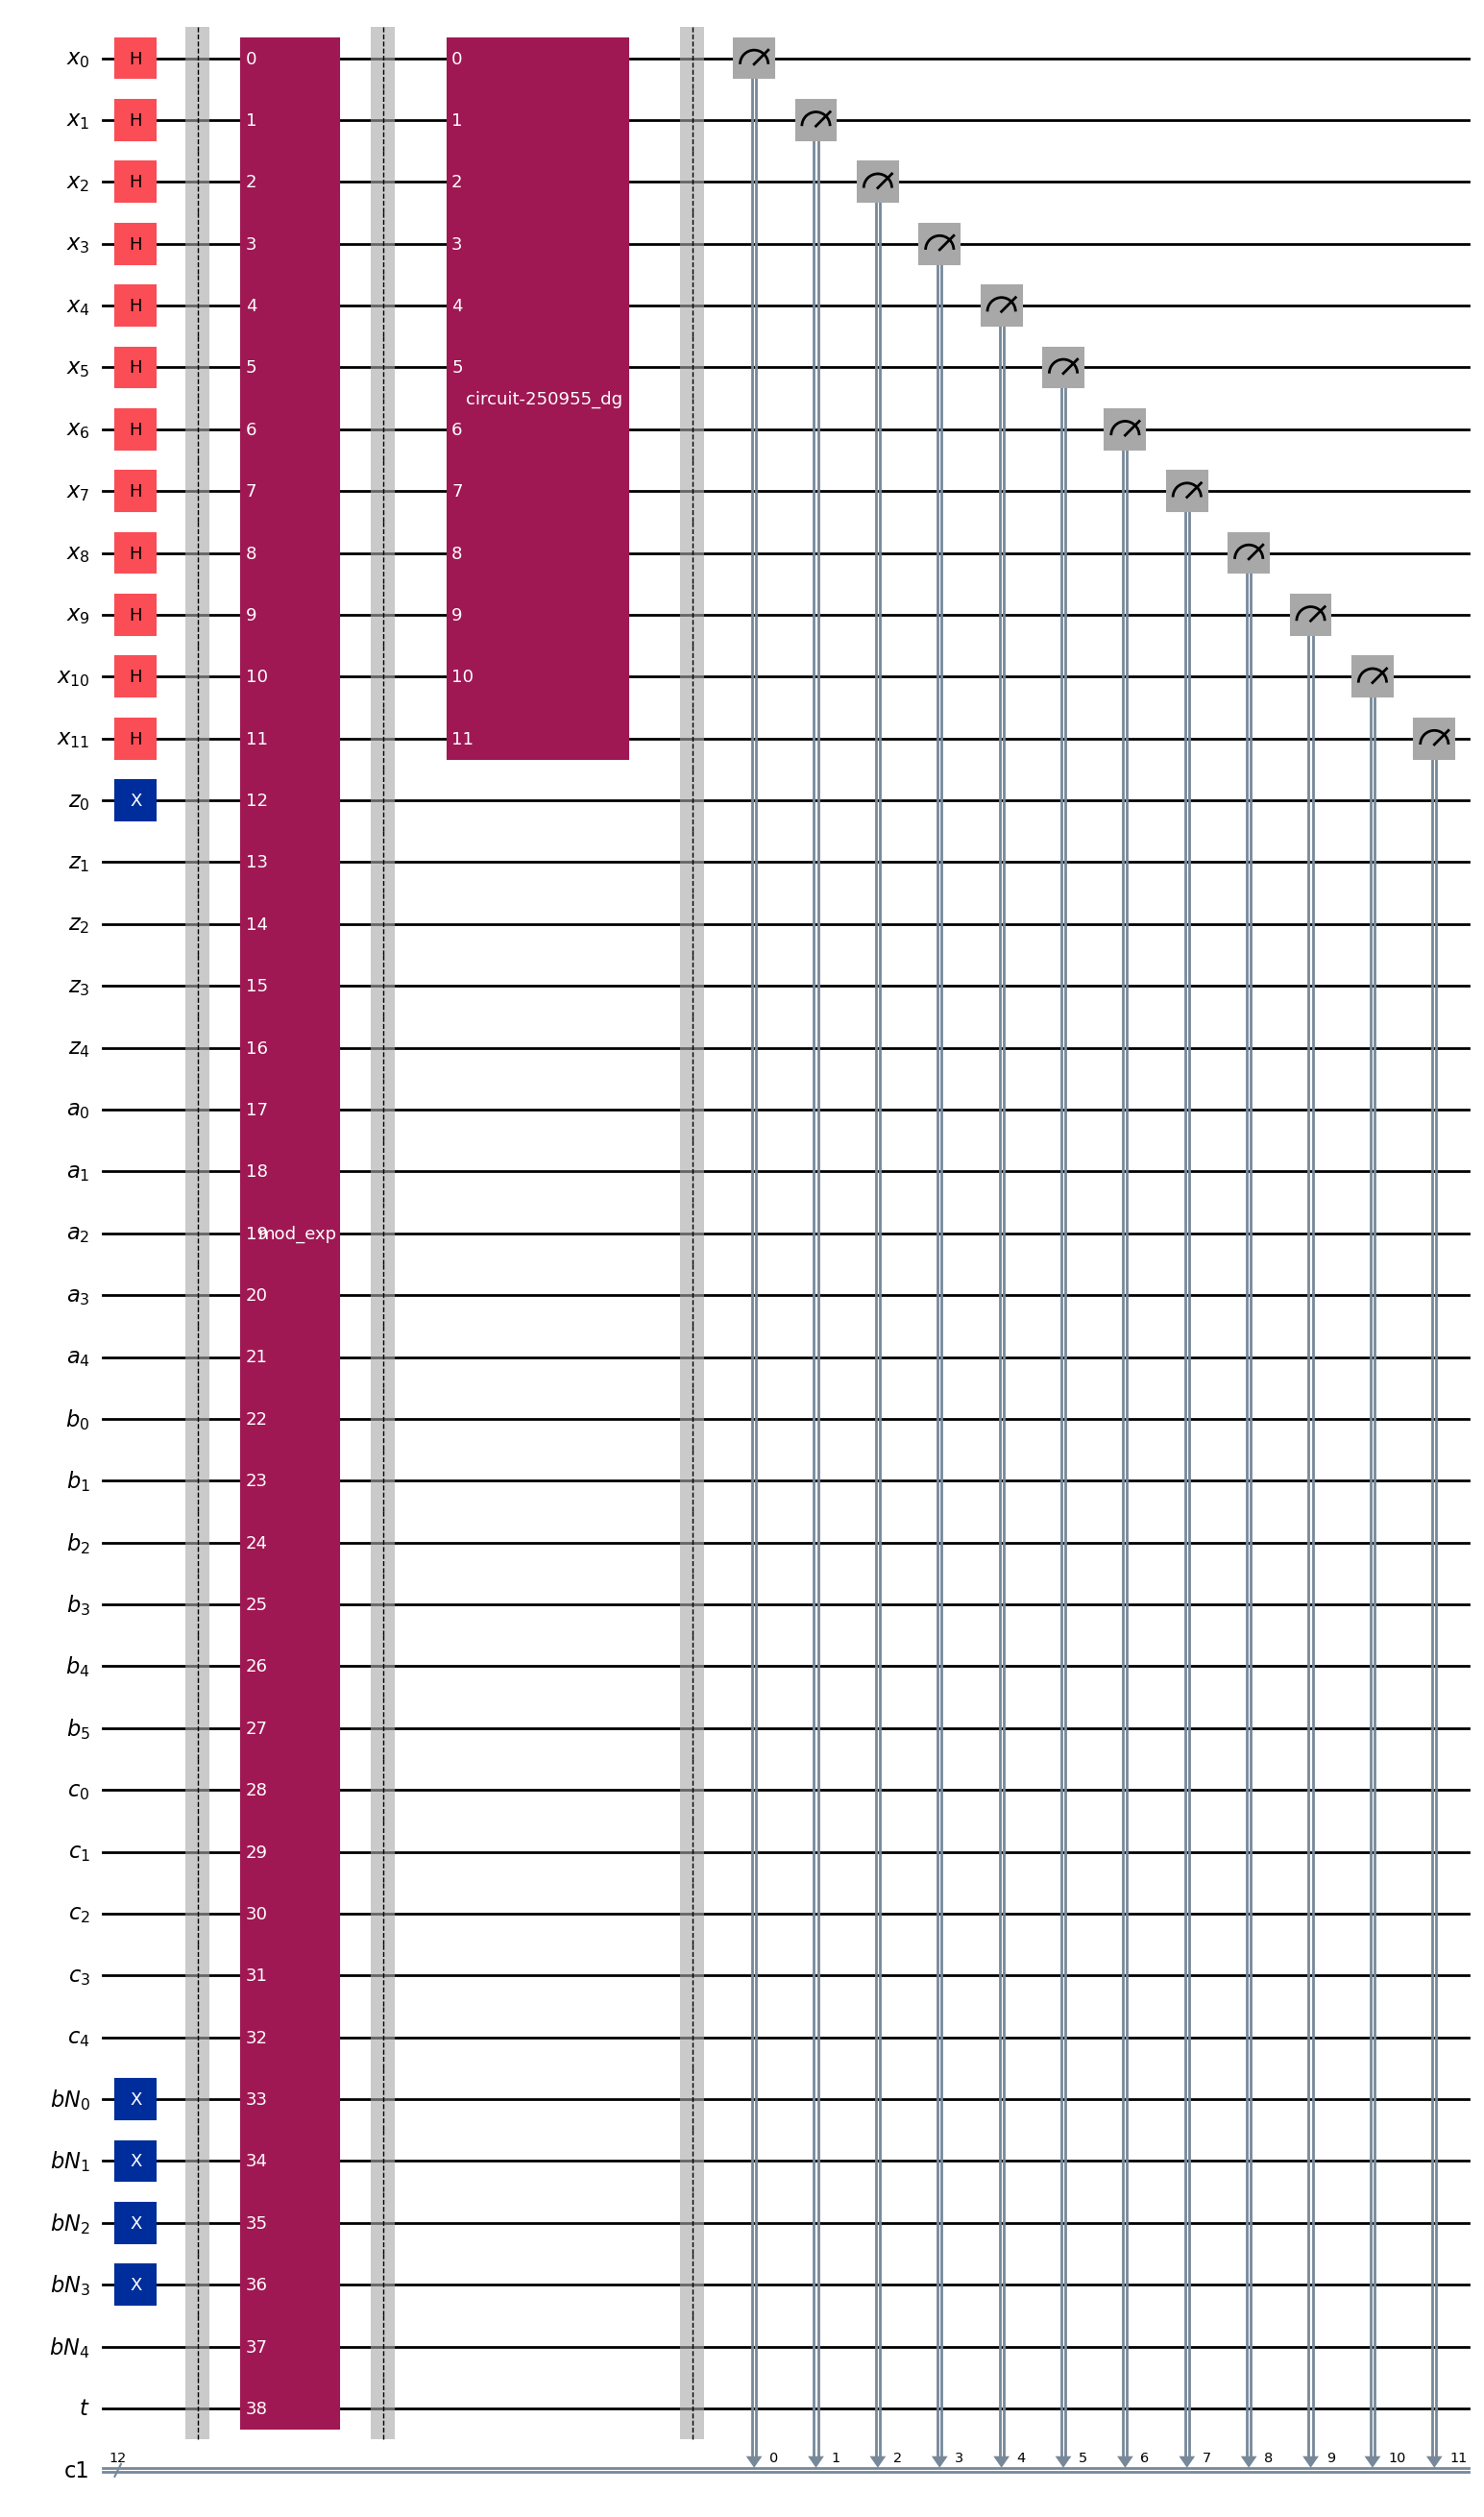

In [108]:
shor_circuit.draw('mpl', fold=-1)